In [75]:
import numpy as np

from spidercat.circuit_extraction import extract_circuit_rooted
import stim

from spidercat import markings
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet, ed
from spidercat.benchmark import benchmark_circuit, sample_circuit


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


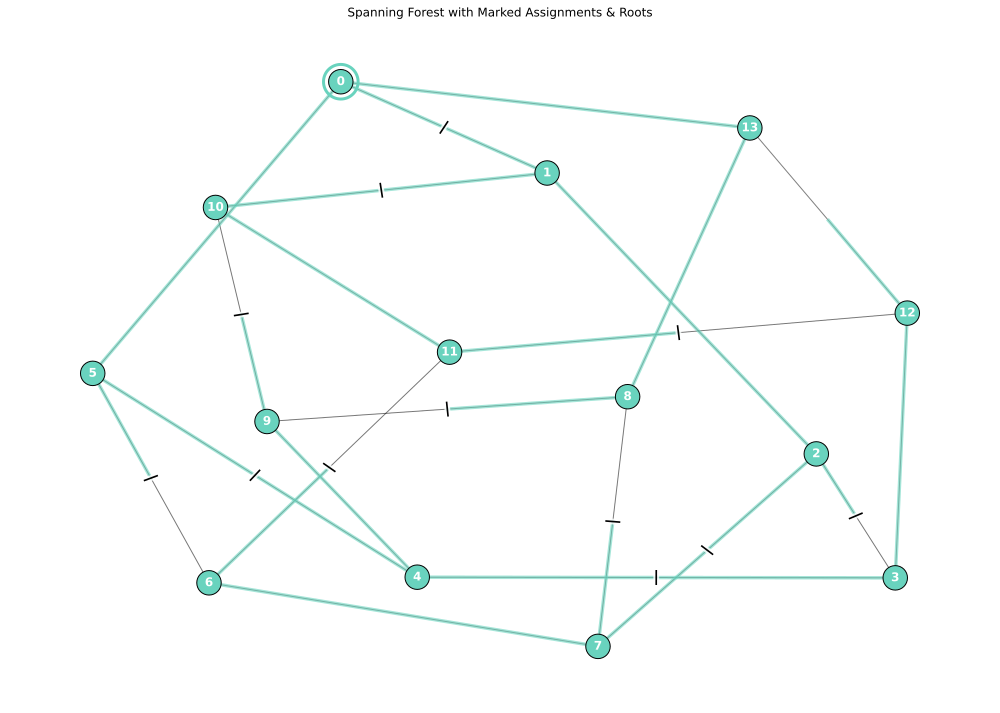

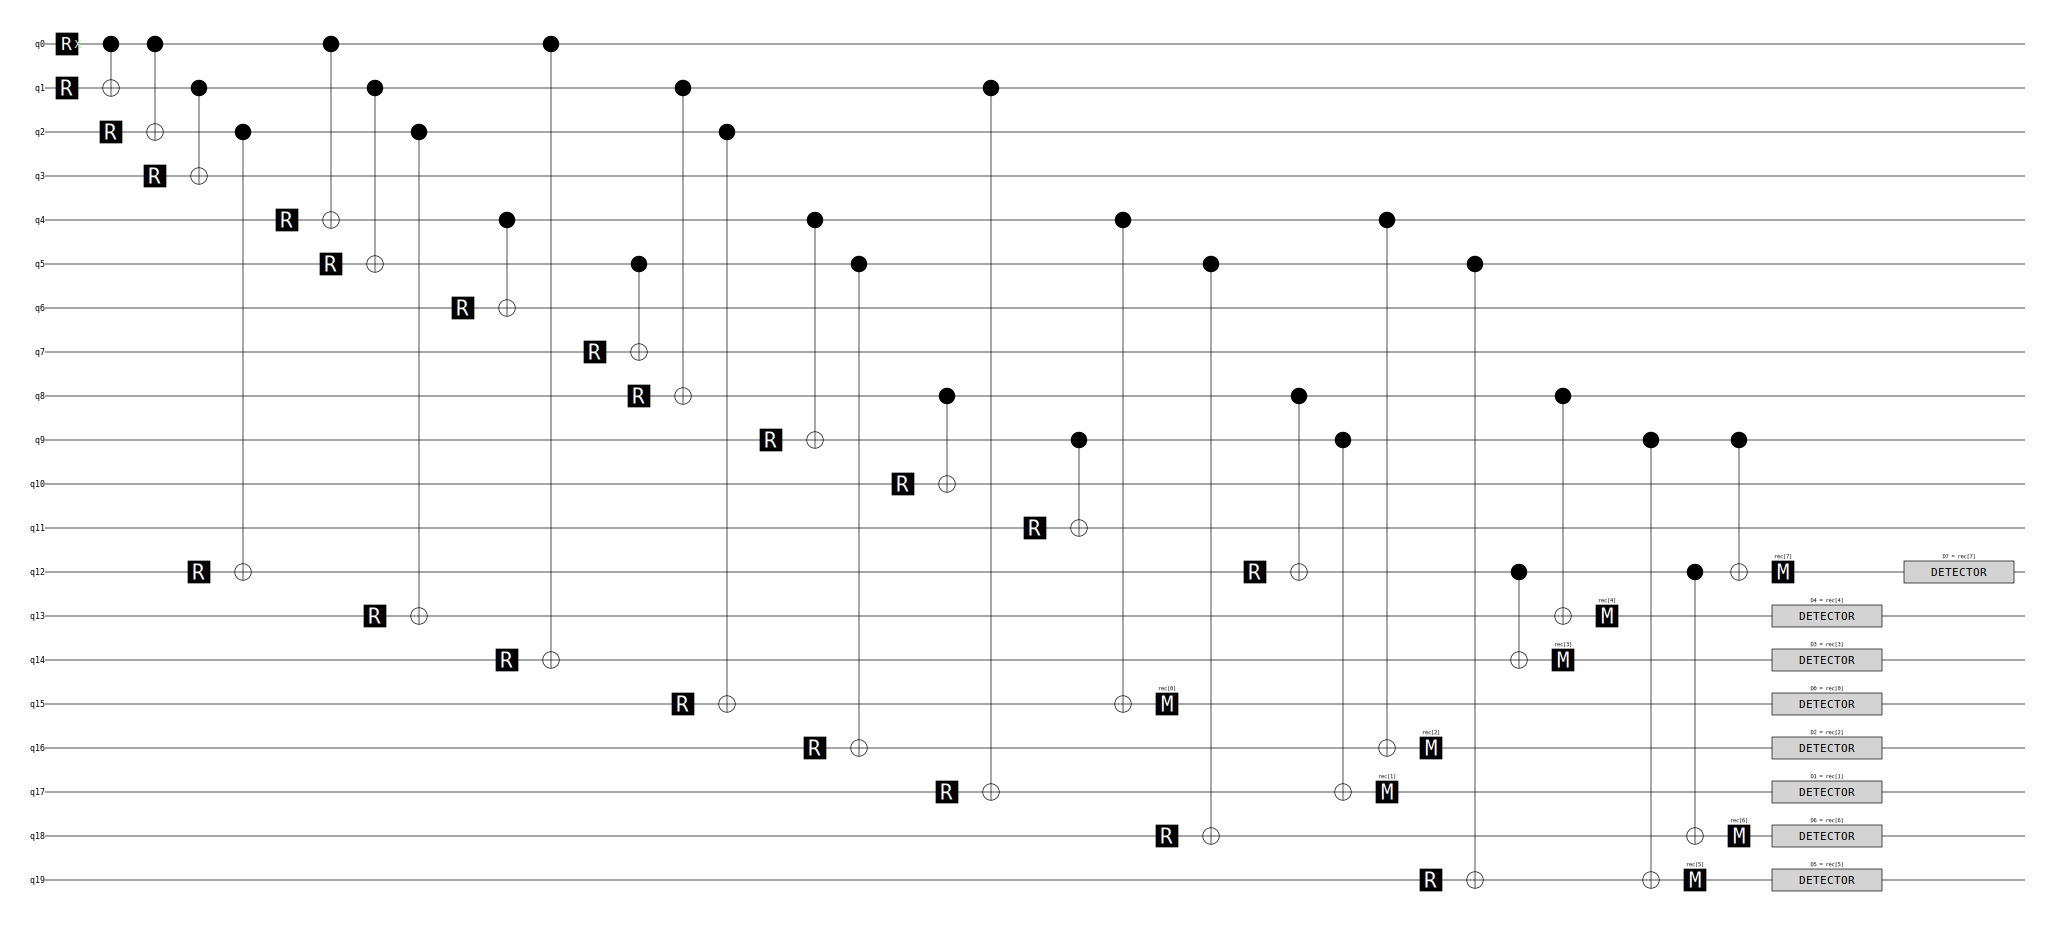

In [76]:
n, t, p = 12, 5, 1
P_CONST = 0.1
grf, forest, M, matchings = load_solution_triplet(n, t, 1)
roots = find_min_height_roots(forest)

matchings = match_forest_leaves_to_marked_edges(grf, forest, M)
roots = find_min_height_roots(forest)
draw_spanning_forest_solution(grf, forest, M, matchings, roots)

circ = extract_circuit_rooted(grf, forest, roots, M, matchings, verbose=False)
# circ.append("DEPOLARIZE1", range(n), 0.05)
circ.diagram('timeline-svg')

In [77]:
og = benchmark_circuit(circ, n, num_samples=5_000_000, p=P_CONST)

Stats for 12-cat (p=0.1): {0: 0.5106245725532125, 1: 0.347046473358679, 2: 0.11180962677362419, 3: 0.024175942324175644, 4: 0.004587306659658281, 5: 0.001326018331307472, 6: 0.0004300599993429639}


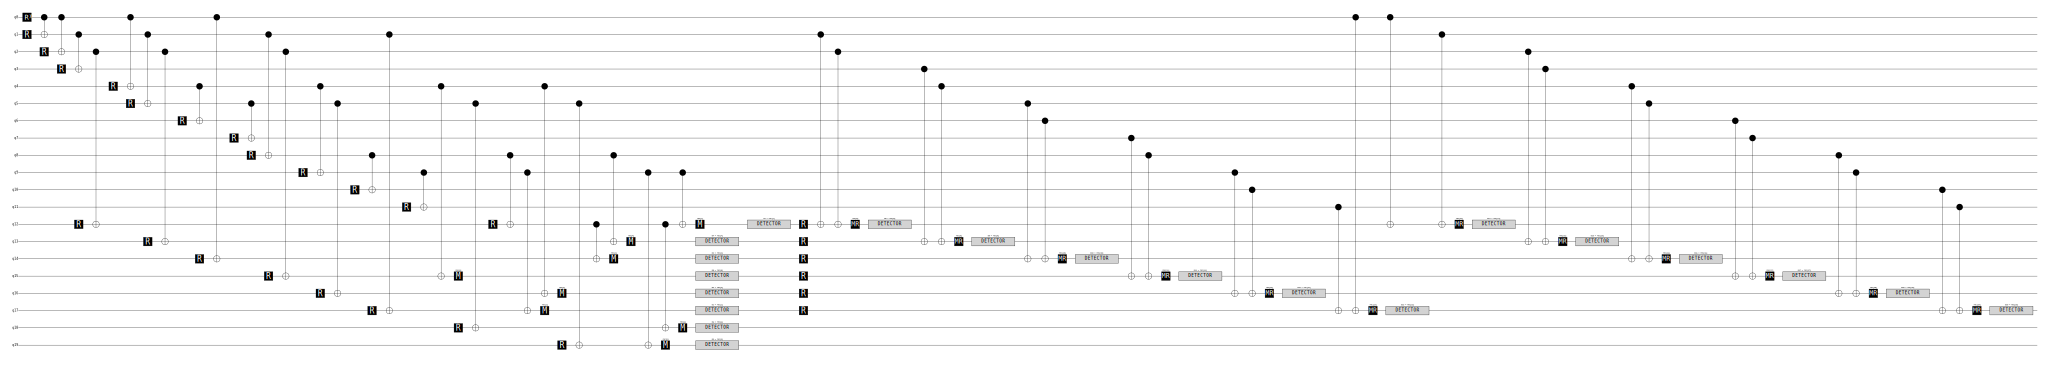

In [78]:
circuit = circ.copy()
circuit.append("R", range(n, n + n // 2))
for i in range(0, n, 2):
    circuit.append("CX", [(i + 1) % n, n + i // 2, (i + 2) % n, n + i // 2])
    circuit.append("MR", n + i // 2)
    circuit.append("DETECTOR", [stim.target_rec(-1)])
for i in range(0, n, 2):
    circuit.append("CX", [i, n + i // 2, i + 1, n + i // 2])
    circuit.append("MR", n + i // 2)
    circuit.append("DETECTOR", [stim.target_rec(-1)])
circuit.diagram('timeline-svg')


In [79]:
new1 = benchmark_circuit(circuit, n, num_samples=10_000_000, p=P_CONST)

Stats for 12-cat (p=0.1): {0: 0.6155500069357748, 1: 0.2888750173394368, 2: 0.07879040088777917, 3: 0.014495769177417118, 4: 0.0019766957969205162, 5: 0.00031210986267166043}


In [80]:
for i in range(max(*new1.keys(), *og.keys())):
    print(f"Probability of {i} faults:\t Original {og.get(i, 0):.2%}  \t vs.\t New: {new1.get(i, 0):.2%}")

Probability of 0 faults:	 Original 51.06%  	 vs.	 New: 61.56%
Probability of 1 faults:	 Original 34.70%  	 vs.	 New: 28.89%
Probability of 2 faults:	 Original 11.18%  	 vs.	 New: 7.88%
Probability of 3 faults:	 Original 2.42%  	 vs.	 New: 1.45%
Probability of 4 faults:	 Original 0.46%  	 vs.	 New: 0.20%
Probability of 5 faults:	 Original 0.13%  	 vs.	 New: 0.03%


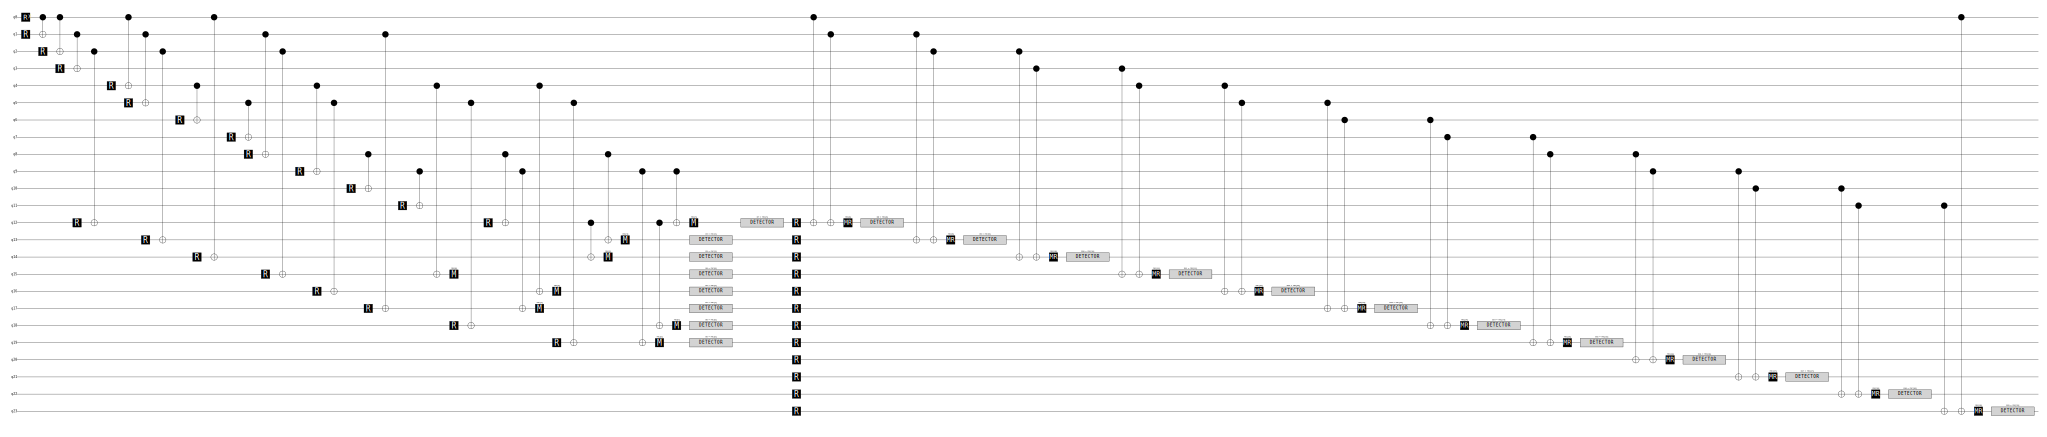

In [81]:
circuit = circ.copy()
circuit.append("R", range(n, n + n))
for i in range(0, n):
    circuit.append("CX", [i , n + i, (i + 1) % n, n + i])
    circuit.append("MR", n + i)
    circuit.append("DETECTOR", [stim.target_rec(-1)])
circuit.diagram('timeline-svg')


In [82]:
new2 = benchmark_circuit(circuit, n, num_samples=10_000_000, p=P_CONST)

Stats for 12-cat (p=0.1): {0: 0.6257713374471331, 1: 0.28627886015392084, 2: 0.07276572141718089, 3: 0.012965402482146572, 4: 0.001802676280940165, 5: 0.00041600221867849963}


In [83]:
for i in range(max(*new1.keys(), *new2.keys(), *og.keys())):
    print(f"Probability of {i} faults:\t Original {og.get(i, 0):.3%} \t vs.\t New1: {new1.get(i, 0):.3%} \t vs.\t New2: {new2.get(i, 0):.3%}")

Probability of 0 faults:	 Original 51.062% 	 vs.	 New1: 61.555% 	 vs.	 New2: 62.577%
Probability of 1 faults:	 Original 34.705% 	 vs.	 New1: 28.888% 	 vs.	 New2: 28.628%
Probability of 2 faults:	 Original 11.181% 	 vs.	 New1: 7.879% 	 vs.	 New2: 7.277%
Probability of 3 faults:	 Original 2.418% 	 vs.	 New1: 1.450% 	 vs.	 New2: 1.297%
Probability of 4 faults:	 Original 0.459% 	 vs.	 New1: 0.198% 	 vs.	 New2: 0.180%
Probability of 5 faults:	 Original 0.133% 	 vs.	 New1: 0.031% 	 vs.	 New2: 0.042%


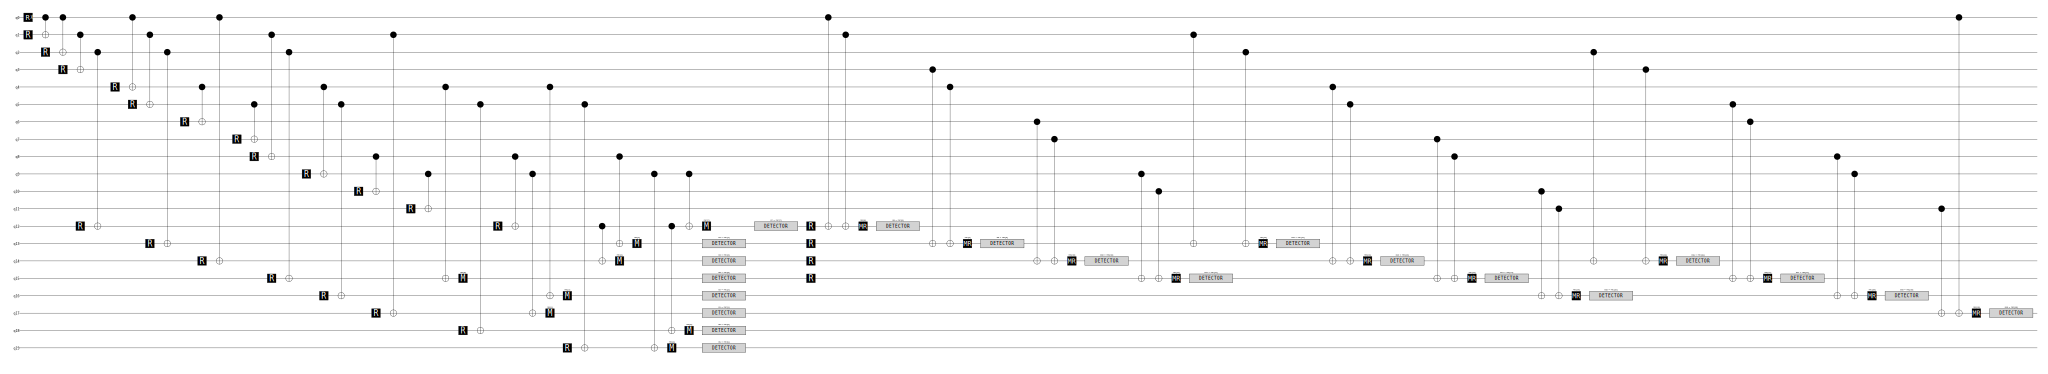

In [84]:
circuit = circ.copy()
K = 3
circuit.append("R", range(n, n + n // K))
for k in range(K):
    for i in range(0, n, K):
        if i + k >= n:
            continue
        circuit.append("CX", [(i + k) % n, n + i // K + k])
        circuit.append("CX", [(i + k + 1) % n, n + i // K + k])
        circuit.append("MR", n + i // K + k)
        circuit.append("DETECTOR", [stim.target_rec(-1)])


circuit.diagram('timeline-svg')

In [85]:
new3 = benchmark_circuit(circuit, n, num_samples=10_000_000, p=P_CONST)

Stats for 12-cat (p=0.1): {0: 0.6294535290905002, 1: 0.28319465415876893, 2: 0.07164198284447586, 3: 0.01333247662800784, 4: 0.002120345680598837, 5: 0.00025701159764834387}


In [86]:
for i in range(max(*new1.keys(), *new2.keys(), *og.keys())):
    print(f"Probability of {i} faults:\t Original {og.get(i, 0):.3%} \t vs.\t New1: {new1.get(i, 0):.3%} \t vs.\t New2: {new2.get(i, 0):.3%} \t vs.\t New3: {new3.get(i, 0):.3%}")

Probability of 0 faults:	 Original 51.062% 	 vs.	 New1: 61.555% 	 vs.	 New2: 62.577% 	 vs.	 New3: 62.945%
Probability of 1 faults:	 Original 34.705% 	 vs.	 New1: 28.888% 	 vs.	 New2: 28.628% 	 vs.	 New3: 28.319%
Probability of 2 faults:	 Original 11.181% 	 vs.	 New1: 7.879% 	 vs.	 New2: 7.277% 	 vs.	 New3: 7.164%
Probability of 3 faults:	 Original 2.418% 	 vs.	 New1: 1.450% 	 vs.	 New2: 1.297% 	 vs.	 New3: 1.333%
Probability of 4 faults:	 Original 0.459% 	 vs.	 New1: 0.198% 	 vs.	 New2: 0.180% 	 vs.	 New3: 0.212%
Probability of 5 faults:	 Original 0.133% 	 vs.	 New1: 0.031% 	 vs.	 New2: 0.042% 	 vs.	 New3: 0.026%


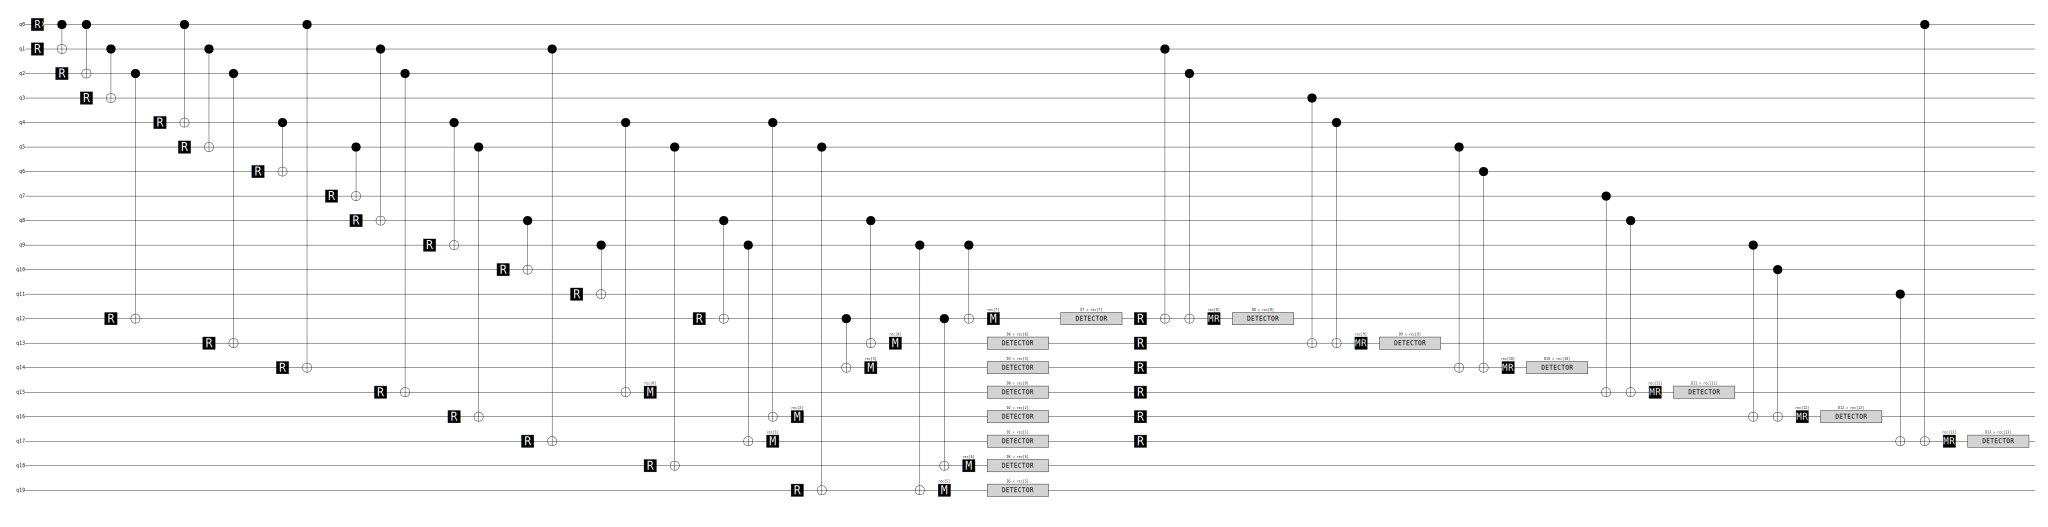

In [96]:
circuit = circ.copy()
circuit.append("R", range(n, n + n // 2))
for i in range(0, n, 2):
    circuit.append("CX", [(i + 1) % n, n + i // 2, (i + 2) % n, n + i // 2])
    circuit.append("MR", n + i // 2)
    circuit.append("DETECTOR", [stim.target_rec(-1)])
circuit.diagram('timeline-svg')


In [97]:
new4 = benchmark_circuit(circuit, n, num_samples=10_000_000, p=P_CONST)

samples = sample_circuit(circuit, n, num_samples=10_000_000, p=P_CONST)
sums = np.sum(samples, axis=1, dtype=np.int32)
samples[sums > n // 2,:] ^= True
fault_per_col = np.sum(samples, axis=0, dtype=np.int32)
print(fault_per_col)

Stats for 12-cat (p=0.1): {0: 0.5948476508896824, 1: 0.29424340983009983, 2: 0.08872563513544249, 3: 0.018498722526743543, 4: 0.0031235547873025983, 5: 0.00047004950682709, 6: 9.097732390201742e-05}
[5608 5339 5405 6375 5700 5696 6351 6353 5711 5612 6485 6343]


In [98]:
for i in range(max(*new1.keys(), *new2.keys(), *og.keys())):
    print(f"Probability of {i} faults:\t Original {og.get(i, 0):.3%} \t vs.\t 2-layer: {new1.get(i, 0):.3%} \t vs.\t n-layer: {new2.get(i, 0):.3%} \t vs.\t 3-layer: {new3.get(i, 0):.3%} \t vs.\t half-2-layer: {new4.get(i, 0):.3%}")

Probability of 0 faults:	 Original 51.062% 	 vs.	 2-layer: 61.555% 	 vs.	 n-layer: 62.577% 	 vs.	 3-layer: 62.945% 	 vs.	 half-2-layer: 59.485%
Probability of 1 faults:	 Original 34.705% 	 vs.	 2-layer: 28.888% 	 vs.	 n-layer: 28.628% 	 vs.	 3-layer: 28.319% 	 vs.	 half-2-layer: 29.424%
Probability of 2 faults:	 Original 11.181% 	 vs.	 2-layer: 7.879% 	 vs.	 n-layer: 7.277% 	 vs.	 3-layer: 7.164% 	 vs.	 half-2-layer: 8.873%
Probability of 3 faults:	 Original 2.418% 	 vs.	 2-layer: 1.450% 	 vs.	 n-layer: 1.297% 	 vs.	 3-layer: 1.333% 	 vs.	 half-2-layer: 1.850%
Probability of 4 faults:	 Original 0.459% 	 vs.	 2-layer: 0.198% 	 vs.	 n-layer: 0.180% 	 vs.	 3-layer: 0.212% 	 vs.	 half-2-layer: 0.312%
Probability of 5 faults:	 Original 0.133% 	 vs.	 2-layer: 0.031% 	 vs.	 n-layer: 0.042% 	 vs.	 3-layer: 0.026% 	 vs.	 half-2-layer: 0.047%


In [99]:
import numpy as np

samples = sample_circuit(circ, n, num_samples=10_000_000, p=P_CONST)
sums = np.sum(samples, axis=1, dtype=np.int32)
samples[sums > n // 2,:] ^= True
fault_per_col = np.sum(samples, axis=0, dtype=np.int32)
print(fault_per_col)

[26402 26077 28694 53788 26489 26267 51995 52098 28101 24603 52208 51969]


[(7447, 10), (7398, 7), (7390, 11), (7345, 3), (6627, 6), (6018, 2), (5976, 1), (5682, 8), (5647, 5), (5593, 9), (5229, 4), (5130, 0)]


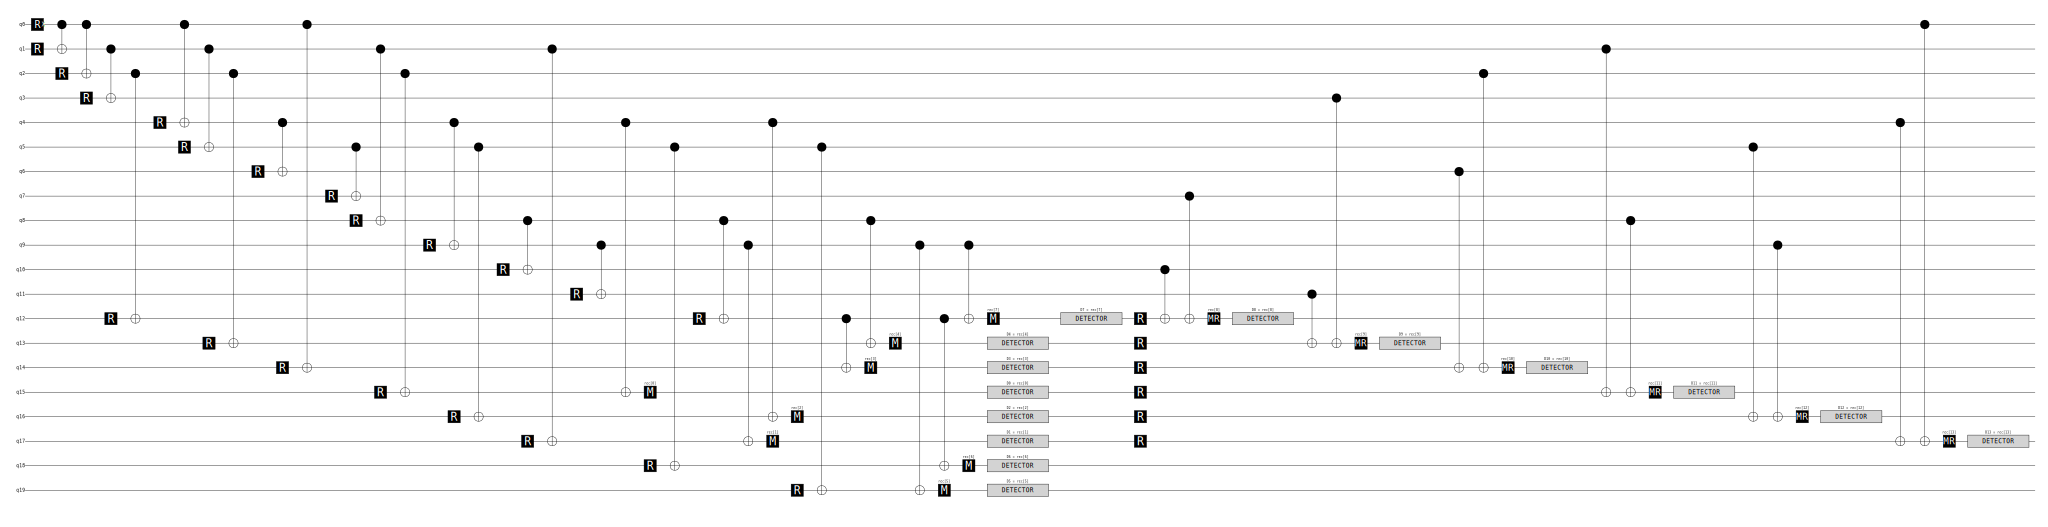

In [111]:
faults = list(zip(fault_per_col.tolist(), range(n)))
faults.sort(reverse=True)
k = n // 2
circuit = circ.copy()
circuit.append("R", range(n, n + k))
for i in range(0, k * 2, 2):
    q1, q2 = faults[i][1], faults[i + 1][1]
    circuit.append("CX", [q1, n + i // 2, q2, n + i // 2])
    circuit.append("MR", n + i // 2)
    circuit.append("DETECTOR", [stim.target_rec(-1)])
print(faults)
circuit.diagram('timeline-svg')

In [112]:
smart_pairing = benchmark_circuit(circuit, n, num_samples=10_000_000, p=P_CONST)

Stats for 12-cat (p=0.1): {0: 0.5922506718198013, 1: 0.2918339925722395, 2: 0.09217518644886621, 3: 0.019399740330323982, 4: 0.00372142878710106, 5: 0.0005057519852652556, 6: 0.00011322805640266916}


In [113]:
 for i in range(max(*new1.keys(), *new2.keys(), *og.keys())):
    print(f"Probability of {i} faults:\t Original {og.get(i, 0):.3%} \t vs.\t 2-layer: {new1.get(i, 0):.3%} \t vs.\t n-layer: {new2.get(i, 0):.3%} \t vs.\t 3-layer: {new3.get(i, 0):.3%} \t vs.\t half-2-layer: {new4.get(i, 0):.3%} \t vs.\t Smart pairing: {smart_pairing.get(i, 0):.3%}")

Probability of 0 faults:	 Original 51.062% 	 vs.	 2-layer: 61.555% 	 vs.	 n-layer: 62.577% 	 vs.	 3-layer: 62.945% 	 vs.	 half-2-layer: 59.485% 	 vs.	 Smart pairing: 59.225%
Probability of 1 faults:	 Original 34.705% 	 vs.	 2-layer: 28.888% 	 vs.	 n-layer: 28.628% 	 vs.	 3-layer: 28.319% 	 vs.	 half-2-layer: 29.424% 	 vs.	 Smart pairing: 29.183%
Probability of 2 faults:	 Original 11.181% 	 vs.	 2-layer: 7.879% 	 vs.	 n-layer: 7.277% 	 vs.	 3-layer: 7.164% 	 vs.	 half-2-layer: 8.873% 	 vs.	 Smart pairing: 9.218%
Probability of 3 faults:	 Original 2.418% 	 vs.	 2-layer: 1.450% 	 vs.	 n-layer: 1.297% 	 vs.	 3-layer: 1.333% 	 vs.	 half-2-layer: 1.850% 	 vs.	 Smart pairing: 1.940%
Probability of 4 faults:	 Original 0.459% 	 vs.	 2-layer: 0.198% 	 vs.	 n-layer: 0.180% 	 vs.	 3-layer: 0.212% 	 vs.	 half-2-layer: 0.312% 	 vs.	 Smart pairing: 0.372%
Probability of 5 faults:	 Original 0.133% 	 vs.	 2-layer: 0.031% 	 vs.	 n-layer: 0.042% 	 vs.	 3-layer: 0.026% 	 vs.	 half-2-layer: 0.047% 	 vs.	 S

In [109]:
samples = sample_circuit(circuit, n, num_samples=10_000_000, p=P_CONST)
sums = np.sum(samples, axis=1, dtype=np.int32)
samples[sums > n // 2,:] ^= True
fault_per_col = np.sum(samples, axis=0, dtype=np.int32)
print(fault_per_col)

[5130 5976 6018 7345 5229 5647 6627 7398 5682 5593 7447 7390]


In [ ]:
[5608, 5339, 5405, 6375, 5700, 5696, 6351, 6353, 5711, 5612, 6485, 6343]

[5780, 5959, 5627, 6569, 5874, 5755, 6432, 6475, 5593, 5776, 6599, 6537]